# Reproducing Stamatelos & Labeas (2023) with `panels.multidomain.MultiDomain`

**Paper.** D. G. Stamatelos, G. N. Labeas, *Buckling Analysis of Laminated Stiffened Plates with
Material Anisotropy Using the Rayleigh-Ritz Approach*, **Computation** 2023, 11, 110.
[doi:10.3390/computation11060110](https://doi.org/10.3390/computation11060110)

This notebook is the `MultiDomain` counterpart of `stamatelos_labeas_2023.ipynb`. That notebook models
the plate with a single `Shell` domain and every blade with the beam formulation of `BladeStiff1D`.
Here the structure is assembled from several `plate_clpt_donnell` domains, connected by penalty
springs, and every connection strategy of `MultiDomain.get_kC_conn()` is exercised:

| connection | used for | paper item |
|---|---|---|
| `'SSycte'` | skin split in strips along `y` | Table 3, Figure 7 |
| `'SSxcte'` | skin split in strips along `x` | Table 2 |
| `'BFycte'` | blade as a plate domain standing on the skin | Tables 4 and 5, Figures 5 to 8 |
| `'BFxcte'` | the same stiffened plate rotated by 90 degrees | Tables 4 and 5 |
| `'SB'`, `'SB_TSL'` | unsymmetric skin split in two bonded sub-laminates | Table 3 |

Each result is compared three ways: against the paper, against the single-domain `StiffPanelBay`
model of the companion notebook, and between the `MultiDomain` variants themselves.

## Read this first

* The published values, laminates and single-domain helpers are **imported** from
  `tests/tests_stiffpanelbay/test_stamatelos_labeas_2023.py`, so this notebook, the companion notebook
  and both test modules share one source of truth. The remarks of the companion notebook on the
  paper itself (Table 2 against Figure 7, the missing absolute scale of Section 3.1.2, the Table 5
  triangular entry) apply unchanged and are not repeated here.
* Tables 3, 4 and 5 are compared through the **same single factor** calibrated on mode (1, 1) of
  Table 3 with the single-domain model. Nothing is re-fitted for `MultiDomain`.
* The penalty constants default to `calc_kt_kr()`. For these thin skins the default rotation penalty
  is soft and leaves a converged error of about 2 %. Where more digits are wanted, the penalties are
  raised by `PENALTY_FACTOR` through the keys `'kt'` and `'kr'` of the connection dictionaries.
  Section 3 quantifies this.

The same checks run as unit tests in `tests/multidomain/test_stamatelos_labeas_2023_multidomain.py`.

In [1]:
import os
import sys
import time
sys.path.append('..')          # run this notebook from the repository
sys.path.append(os.path.join('..', 'tests', 'tests_stiffpanelbay'))

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.sparse import coo_matrix, csr_matrix

import panels
import panels.bardell as bardell
from panels.shell import Shell
from panels.multidomain import MultiDomain
from panels.multidomain.connections import calc_kt_kr
from composites import laminated_plate
from structsolve import lb

# single source of truth: published values, laminates and the single-domain model
import test_stamatelos_labeas_2023 as spb
from test_stamatelos_labeas_2023 import (PAPER, LAMINATES, PLY_T,
        LAMINAPROP_311, A_311, B_311, LAMINAPROP_312, STACK_312, T_312, A_312,
        B_312, H_321, A_322, B_322, N_STIFF_322, STIFF_STACK_322)

print('panels', panels.__version__)
np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})
T0 = time.time()

panels 0.6.13


## 1. Helper functions

**Domains.** Every skin strip, blade and sub-laminate is a simply supported `plate_clpt_donnell`
`Shell`. An edge that is connected to another domain is *released* (`u = v = w` free), because the
connection is then what enforces compatibility.

**Linearly varying load.** Eq. (18) of the paper, $N_x(y) = N_x\,(1 - \varphi\,y/b)$, is integrated
per domain with the Bardell functions, with the weight evaluated at the *global* `y` of the domain,
`y = y0 + b_domain (1 + eta)/2`. For a single domain this is exactly the `kG_linear` of the companion
notebook; for the rotated model (`direction='y'`) the same load acts as $N_y(x)$.

**Blade as a plate.** The `'BFycte'` connection ties the blade root to the skin *mid-surface*, so the
blade domain is extended by `t_skin/2` to reach the same tip as a blade of height `h` standing on the
skin surface, which is the geometry of the paper and of `BladeStiff1D`. The blade ends are simply
supported but free to move along the blade axis: forcing `u = 0` over the whole height would clamp
the blade against bending, which the skin does not do.

In [2]:
PENALTY_FACTOR = 100.


def plate(a, b, stack, m, n, laminaprop=LAMINAPROP_312, **kwargs):
    # Simply supported plate domain, as in spb.make_skin
    return Shell(a=a, b=b, r=None, stack=stack, plyt=PLY_T,
                 laminaprop=laminaprop, rho=1600., model='plate_clpt_donnell',
                 m=m, n=n, **kwargs)


def release(p, *edges):
    # Free the three translations of the given edges (rotations are already free)
    for edge in edges:
        for dof in ('u', 'v', 'w'):
            setattr(p, edge + dof, 1.)


def penalties(p1, p2, connection_type, factor):
    # Connection keys 'kt' and 'kr', scaled from the calc_kt_kr() defaults
    kt, kr = calc_kt_kr(p1, p2, connection_type)
    return dict(kt=factor*kt, kr=factor*kr)


def kG_linear(p, N, phi, s0, s_total, size, direction='x', npts=80):
    # kG of one domain for N*(1 - phi*s/s_total), s = y (direction='x') or x ('y')
    m, n, a, b = p.m, p.n, p.a, p.b
    xi, wt = leggauss(npts)
    if direction == 'x':
        dfx = np.array([bardell.calc_vec_fp(x, p.x1w, p.x1wr, p.x2w, p.x2wr)[:m]
                        for x in xi])
        fy = np.array([bardell.calc_vec_f(e, p.y1w, p.y1wr, p.y2w, p.y2wr)[:n]
                       for e in xi])
        Fx = (dfx.T*wt) @ dfx
        Fy = (fy.T*(wt*(1. - phi*(s0 + b*(1. + xi)/2.)/s_total))) @ fy
        scale = b/a
    else:
        fx = np.array([bardell.calc_vec_f(x, p.x1w, p.x1wr, p.x2w, p.x2wr)[:m]
                       for x in xi])
        dfy = np.array([bardell.calc_vec_fp(e, p.y1w, p.y1wr, p.y2w, p.y2wr)[:n]
                        for e in xi])
        Fx = (fx.T*(wt*(1. - phi*(s0 + a*(1. + xi)/2.)/s_total))) @ fx
        Fy = (dfy.T*wt) @ dfy
        scale = a/b
    blk = N*scale*np.einsum('ik,jl->jilk', Fx, Fy).reshape(m*n, m*n)
    idx = p.row_start + 3*np.arange(m*n) + 2          # w is the 3rd dof
    rows, cols = np.meshgrid(idx, idx, indexing='ij')
    return coo_matrix((blk.ravel(), (rows.ravel(), cols.ravel())),
                      shape=(size, size)).tocsr()


def buckling(md, kG, num_eigvalues=6, c=None):
    kC = md.calc_kC(c=c, silent=True)
    return lb(csr_matrix(kC), csr_matrix(kG), silent=True,
              num_eigvalues=num_eigvalues)


def strips(a, b, stack, nstrip, m, n, along, factor, laminaprop=LAMINAPROP_312):
    # Skin split in nstrip equal strips, connected with 'SSycte' or 'SSxcte'
    if along == 'y':
        edges = np.linspace(0, b, nstrip + 1)
        skins = [plate(a, y2 - y1, stack, m, n, laminaprop, x0=0., y0=y1,
                       group='skin') for y1, y2 in zip(edges[:-1], edges[1:])]
        conn = [dict(p1=p1, p2=p2, func='SSycte', ycte1=p1.b, ycte2=0.,
                     **penalties(p1, p2, 'ycte', factor))
                for p1, p2 in zip(skins[:-1], skins[1:])]
        for p1, p2 in zip(skins[:-1], skins[1:]):
            release(p1, 'y2')
            release(p2, 'y1')
    else:
        edges = np.linspace(0, a, nstrip + 1)
        skins = [plate(x2 - x1, b, stack, m, n, laminaprop, x0=x1, y0=0.,
                       group='skin') for x1, x2 in zip(edges[:-1], edges[1:])]
        conn = [dict(p1=p1, p2=p2, func='SSxcte', xcte1=p1.a, xcte2=0.,
                     **penalties(p1, p2, 'xcte', factor))
                for p1, p2 in zip(skins[:-1], skins[1:])]
        for p1, p2 in zip(skins[:-1], skins[1:]):
            release(p1, 'x2')
            release(p2, 'x1')
    return skins, conn


def blade(length, height, stack, m, n, along, laminaprop=LAMINAPROP_312,
          t_skin=T_312):
    # Blade as a plate domain, attached by its edge y = 0 ('x') or x = 0 ('y')
    h = height + t_skin/2
    if along == 'x':
        f = plate(length, h, stack, m, n, laminaprop, x0=0., y0=0., group='blade')
        release(f, 'y1', 'y2')
        f.x1u = f.x2u = 1.
    else:
        f = plate(h, length, stack, m, n, laminaprop, x0=0., y0=0., group='blade')
        release(f, 'x1', 'x2')
        f.y1v = f.y2v = 1.
    return f


def rotate(stack):
    return [theta + 90 for theta in stack]


def plot_md_mode(ax, md, c, title, group='skin', blade_ys=(), gridx=80,
                 gridy=30):
    # w of all domains of a group, in global coordinates, normalised to max|w| = 1
    ps = [p for p in md.panels if p.group == group]
    res = md.uvw(c, group=group, gridx=gridx, gridy=gridy)
    lim = max(np.abs(w).max() for w in res['w'])
    levels = np.linspace(-1, 1, 22)
    for p, x, y, w in zip(ps, res['x'], res['y'], res['w']):
        cs = ax.contourf((x + p.x0)*1e3, (y + p.y0)*1e3, w/lim, levels=levels,
                         cmap='RdBu_r')
    for y in blade_ys:
        ax.axhline(y*1e3, color='k', lw=1.2, ls='--')
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.grid(False)
    return cs


def pct(value, reference):
    if reference is None or reference == 0:
        return np.nan
    return 100.*(value/reference - 1.)


def show(rows, header):
    widths = [max(len(header[i]), max(len(str(r[i])) for r in rows)) + 2
              for i in range(len(header))]
    line = ''.join(h.rjust(w) for h, w in zip(header, widths))
    print(line)
    print('-'*len(line))
    for r in rows:
        print(''.join(str(c).rjust(w) for c, w in zip(r, widths)))

## 2. The load helper and the scale factor

`kG_linear` placed at the rows of a single domain at `(x0, y0) = (0, 0)` must be the matrix of the
companion notebook. The scale factor of Tables 3 to 5 is then taken from the single-domain model,
exactly as in the companion notebook.

In [3]:
p = plate(A_312, B_312, STACK_312, 16, 16)
p.row_start = 0
size = p.get_size()
err = 0.
for phi in (0., 1.):
    k_md = kG_linear(p, -1., phi, 0., B_312, size).toarray()
    k_sd = spb.kG_linear(spb.make_skin(A_312, B_312, STACK_312, PLY_T,
                                       LAMINAPROP_312), -1., phi).toarray()
    err = max(err, np.abs(k_md - k_sd).max()/np.abs(k_sd).max())
print('kG_linear per domain vs single-domain helper: max rel. diff = %.2e' % err)
assert err < 1e-12

SCALE, EV_SD_T3 = spb.table3_scale()
print('scale factor of Table 3, from the single-domain model: %.5f' % SCALE)

kG_linear per domain vs single-domain helper: max rel. diff = 1.37e-16


scale factor of Table 3, from the single-domain model: 4.73840


## 3. `'SSycte'` and `'SSxcte'` - penalty stiffness and convergence

The Section 3.1.2 plate under the triangular load is split in three equal strips, first along `y`
(`'SSycte'`, connections parallel to the load) then along `x` (`'SSxcte'`, connections across the
load). The split models must recover the single-domain eigenvalues. Penalty methods are always too
flexible, so the error must be negative and shrink as the penalties grow.

In [4]:
skin_sd = spb.make_skin(A_312, B_312, STACK_312, PLY_T, LAMINAPROP_312)
ref_sd, _ = spb.buckling(skin_sd, phi=1.)

factors = (0.1, 1., 10., 100., 1000.)
res_pen = {}
for along, (m, n) in (('y', (12, 8)), ('x', (8, 12))):
    for factor in factors:
        skins, conn = strips(A_312, B_312, STACK_312, 3, m, n, along, factor)
        mdom = MultiDomain(skins, conn)
        size = mdom.get_size()
        kG = sum(kG_linear(p, -1., 1., p.y0, B_312, size) for p in skins)
        ev, _ = buckling(mdom, kG)
        res_pen[(along, factor)] = ev

print('3 strips, triangular load: per cent difference to the single domain')
rows = []
for along, func in (('y', 'SSycte'), ('x', 'SSxcte')):
    for factor in factors:
        ev = res_pen[(along, factor)]
        rows.append([func, '%g' % factor] + ['%+.4f' % pct(ev[i], ref_sd[i])
                                             for i in range(3)])
show(rows, ['connection', 'kt, kr x', 'mode 1', 'mode 2', 'mode 3'])

s1, s2 = strips(A_312, B_312, STACK_312, 3, 12, 8, 'y', 1.)[0][:2]
kt, kr = calc_kt_kr(s1, s2, 'ycte')
print('\ncalc_kt_kr defaults for these strips: kt = %.3e N/m^2, kr = %.3e N' % (kt, kr))

3 strips, triangular load: per cent difference to the single domain
  connection  kt, kr x    mode 1   mode 2   mode 3
--------------------------------------------------
      SSycte       0.1  -15.6134  -4.8098  -2.3246
      SSycte         1   -2.0113  -0.6163  -0.2951
      SSycte        10   -0.2071  -0.0634  -0.0302
      SSycte       100   -0.0208  -0.0064  -0.0029
      SSycte      1000   -0.0021  -0.0006  -0.0001
      SSxcte       0.1   -7.1922  -5.4370  -0.0175
      SSxcte         1   -0.3287  -0.9886  -0.0019
      SSxcte        10   -0.0331  -0.0992  -0.0002
      SSxcte       100   -0.0033  -0.0099  +0.0000
      SSxcte      1000   -0.0003  -0.0010  +0.0000

calc_kt_kr defaults for these strips: kt = 4.860e+10 N/m^2, kr = 7.937e+02 N


In [5]:
print("'SSycte', 3 strips, penalties x %g: convergence in the number of terms"
      % PENALTY_FACTOR)
rows = []
for m, n in ((8, 6), (10, 6), (12, 8), (14, 8), (16, 10)):
    skins, conn = strips(A_312, B_312, STACK_312, 3, m, n, 'y', PENALTY_FACTOR)
    mdom = MultiDomain(skins, conn)
    size = mdom.get_size()
    kG = sum(kG_linear(p, -1., 1., p.y0, B_312, size) for p in skins)
    ev, _ = buckling(mdom, kG)
    rows.append(['%d x %d' % (m, n), size] +
                ['%+.4f' % pct(ev[i], ref_sd[i]) for i in range(3)])
show(rows, ['m x n', 'dofs', 'mode 1 %', 'mode 2 %', 'mode 3 %'])

'SSycte', 3 strips, penalties x 100: convergence in the number of terms


    m x n  dofs  mode 1 %  mode 2 %  mode 3 %
---------------------------------------------
    8 x 6   432   -0.0207   -0.0042   +2.0637
   10 x 6   540   -0.0207   -0.0063   +0.0302
   12 x 8   864   -0.0208   -0.0064   -0.0029
   14 x 8  1008   -0.0208   -0.0064   -0.0030
  16 x 10  1440   -0.0208   -0.0064   -0.0030


## 4. Section 3.1.1 / Table 2 - three `'SSxcte'` strips across the load

The five laminates of Table 2, `a = b = 254 mm`, uniform load, **loaded edges clamped** (the
companion notebook shows this is the boundary condition that makes Table 2 consistent with Lagace).
The skin is split in three strips across the loading direction, so the connections carry the full
compressive load, and the clamped rotations sit on the outer edges of the first and last strips.

In [6]:
res_t2 = {}
for name, stack in LAMINATES.items():
    skin = spb.make_skin(A_311, B_311, stack, PLY_T, LAMINAPROP_311,
                         clamped_loaded_edges=True)
    ref, _ = spb.buckling(skin)
    skins, conn = strips(A_311, B_311, stack, 3, 8, 12, 'x', PENALTY_FACTOR,
                         laminaprop=LAMINAPROP_311)
    skins[0].x1wr = 0.
    skins[-1].x2wr = 0.
    mdom = MultiDomain(skins, conn)
    size = mdom.get_size()
    kG = sum(kG_linear(p, -1., 0., 0., B_311, size) for p in skins)
    ev, evec = buckling(mdom, kG)
    res_t2[name] = dict(Nxx=ev[0]/1e3, sd=ref[0]/1e3, md=mdom, evec=evec)

rows = []
for name in LAMINATES:
    r, ref = res_t2[name], PAPER['table2'][name]
    rows.append([name, '%.3f' % r['Nxx'], '%.3f' % r['sd'],
                 '%+.3f' % pct(r['Nxx'], r['sd']), '%.3f' % ref['rr'],
                 '%+.1f' % pct(r['Nxx'], ref['rr']), '%.3f' % ref['lagace_rr'],
                 '%+.1f' % pct(r['Nxx'], ref['lagace_rr'])])
show(rows, ['lamination', 'MultiDomain', 'single dom.', 'diff %',
            'paper R-R', 'diff %', 'Lagace R-R', 'diff %'])

                lamination  MultiDomain  single dom.  diff %  paper R-R  diff %  Lagace R-R  diff %
---------------------------------------------------------------------------------------------------
               [0_3/90_3]s       27.150       27.152  -0.006     26.475    +2.6      27.150    +0.0
       [0_3/90_3/0_3/90_3]       17.256       17.257  -0.004     17.514    -1.5      20.439   -15.6
   [0_2/45_2/0_2/45_2/0_2]       15.943       15.943  -0.005     22.789   -30.0      18.389   -13.3
  [0_2/45_2/0_2/-45_2/0_2]       15.027       15.028  -0.005     20.426   -26.4      17.770   -15.4
                [0_6/60_6]       12.110       12.110  +0.001     17.788   -31.9      18.000   -32.7


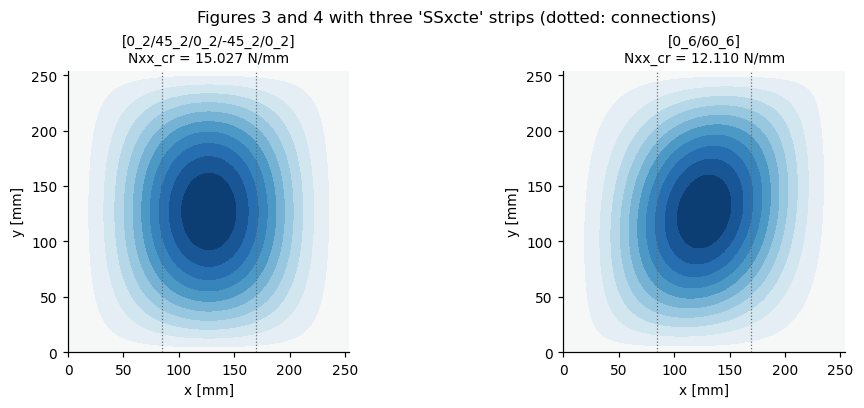

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
for ax, name in zip(axes, ['[0_2/45_2/0_2/-45_2/0_2]', '[0_6/60_6]']):
    r = res_t2[name]
    cs = plot_md_mode(ax, r['md'], r['evec'][:, 0],
                      '%s\nNxx_cr = %.3f N/mm' % (name, r['Nxx']), gridx=40,
                      gridy=60)
    for p in r['md'].panels[1:]:
        ax.axvline(p.x0*1e3, color='0.4', lw=0.8, ls=':')
fig.suptitle("Figures 3 and 4 with three 'SSxcte' strips (dotted: connections)")
plt.show()

## 5. Section 3.1.2 / Table 3 - three `'SSycte'` strips, triangular load

The scale factor is the one of section 2, calibrated on the single-domain model. The split model is
not re-fitted, so mode (1, 1) is itself a check.

  mode (m, n)  MultiDomain  single dom.  diff %  paper R-R  diff %  paper FE  diff %
------------------------------------------------------------------------------------
       (1, 1)       67.735       67.749  -0.021     67.749   -0.02    59.476   +13.9
       (2, 1)       69.440       69.444  -0.006     69.298   +0.20    65.803    +5.5
       (3, 1)      112.961      112.964  -0.003    113.310   -0.31   108.266    +4.3


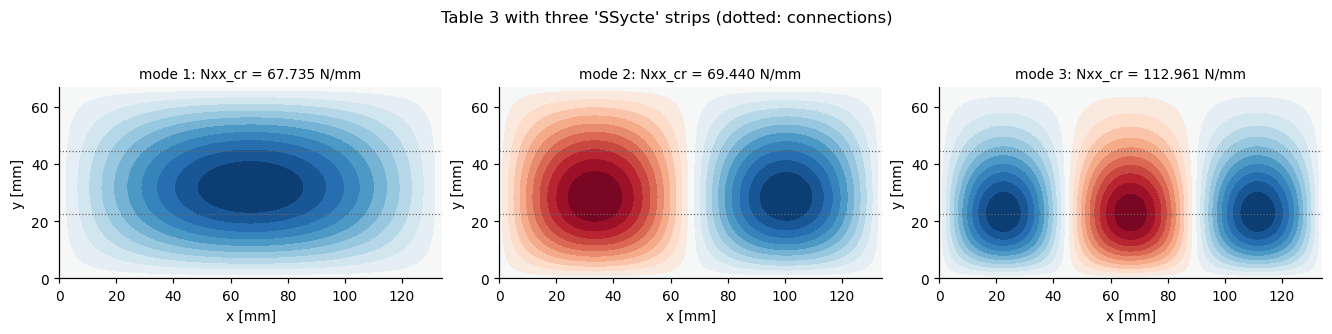

In [8]:
skins, conn = strips(A_312, B_312, STACK_312, 3, 12, 8, 'y', PENALTY_FACTOR)
md_t3 = MultiDomain(skins, conn)
size = md_t3.get_size()
kG = sum(kG_linear(p, -1., 1., p.y0, B_312, size) for p in skins)
ev_t3, evec_t3 = buckling(md_t3, kG)

rows = []
for i, mode in enumerate(['(1, 1)', '(2, 1)', '(3, 1)']):
    ref = PAPER['table3'][mode]
    v = ev_t3[i]/1e3*SCALE
    v_sd = EV_SD_T3[i]/1e3*SCALE
    rows.append([mode, '%.3f' % v, '%.3f' % v_sd, '%+.3f' % pct(v, v_sd),
                 '%.3f' % ref['rr'], '%+.2f' % pct(v, ref['rr']),
                 '%.3f' % ref['fe'], '%+.1f' % pct(v, ref['fe'])])
show(rows, ['mode (m, n)', 'MultiDomain', 'single dom.', 'diff %',
            'paper R-R', 'diff %', 'paper FE', 'diff %'])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.0), constrained_layout=True)
for i, ax in enumerate(axes):
    plot_md_mode(ax, md_t3, evec_t3[:, i],
                 'mode %d: Nxx_cr = %.3f N/mm' % (i + 1, ev_t3[i]/1e3*SCALE))
    for p in md_t3.panels[1:]:
        ax.axhline(p.y0*1e3, color='0.4', lw=0.8, ls=':')
fig.suptitle("Table 3 with three 'SSycte' strips (dotted: connections)")
plt.show()

### The same skin as two bonded sub-laminates: `'SB'` and `'SB_TSL'`

The `[0/90/90/0/0]` skin of Table 3 is unsymmetric, so its buckling load depends on the
bending-extension coupling `B`. Here it is split through the thickness into a bottom `[0/90]` and a
top `[90/0/0]` domain, bonded over their whole area. Each sub-laminate alone has a different `B`, so
the monolithic `B` can only be rebuilt by the offset `dsb` between the two mid-surfaces inside the
connection. The split skin is simply supported with `u = v = 0` on the mid-surface of the top part,
so the monolithic reference is given the same reference surface with `offset`.

`'SB_TSL'` is the traction-separation-law version of the same connection, evaluated for a pristine
interface (zero separation, stiffness `k_o` everywhere). The order of the two domains in the
assembly must not matter.

In [9]:
N_BOTTOM = 2            # plies of the bottom sub-laminate, stack[0] is at -z
M_SB = N_SB = 12


def sb_split(func, order, kt=None):
    top = plate(A_312, B_312, STACK_312[N_BOTTOM:], M_SB, N_SB, x0=0., y0=0.,
                group='top')
    bot = plate(A_312, B_312, STACK_312[:N_BOTTOM], M_SB, N_SB, x0=0., y0=0.,
                group='bottom')
    release(bot, 'x1', 'x2', 'y1', 'y2')    # the bottom only follows the top
    if kt is None:
        kt = PENALTY_FACTOR*calc_kt_kr(top, bot, 'bot-top')[0]
    if func == 'SB':
        conn = [dict(p1=top, p2=bot, func='SB', kt=kt)]
    else:
        conn = [dict(p1=top, p2=bot, func='SB_TSL', tsl_type='bilinear',
                     k_o=kt, tau_o=1e30, G1c=1e30, nr_x_gauss=2*M_SB,
                     nr_y_gauss=2*N_SB)]
    mdom = MultiDomain([top, bot] if order == 'top first' else [bot, top],
                       conn)
    size = mdom.get_size()
    c = np.zeros(size) if func == 'SB_TSL' else None
    kG = kG_linear(top, -1., 1., 0., B_312, size)   # w is common to both
    ev, _ = buckling(mdom, kG, num_eigvalues=4, c=c)
    return ev


def sb_monolithic(offset=True):
    h_bottom = N_BOTTOM*PLY_T
    mono = plate(A_312, B_312, STACK_312, M_SB, N_SB,
                 offset=-h_bottom/2 if offset else 0.)
    mono.row_start = 0
    size = mono.get_size()
    ev, _ = lb(mono.calc_kC(silent=True),
               kG_linear(mono, -1., 1., 0., B_312, size), silent=True,
               num_eigvalues=4)
    return ev


ev_mono = sb_monolithic()
rows = [['monolithic, offset', '-'] + ['%.4f' % (e/1e3) for e in ev_mono[:3]]
        + ['-']]
res_sb = {}
for func in ('SB', 'SB_TSL'):
    for order in ('top first', 'bottom first'):
        ev = sb_split(func, order)
        res_sb[(func, order)] = ev
        rows.append([func, order] + ['%.4f' % (e/1e3) for e in ev[:3]]
                    + ['%+.3f' % pct(ev[0], ev_mono[0])])
ev_old = sb_split('SB', 'top first', kt=2e5)
rows.append(["'SB', kt = 2e5 (<= 0.6.9)", 'top first']
            + ['%.4f' % (e/1e3) for e in ev_old[:3]]
            + ['%+.1f' % pct(ev_old[0], ev_mono[0])])
print('triangular load, raw N/mm (not scaled):')
show(rows, ['model', 'order', 'mode 1', 'mode 2', 'mode 3', 'mode 1 diff %'])

ev_mid = sb_monolithic(offset=False)
print('\nfor reference, the monolithic skin supported on its own mid-surface:'
      ' mode 1 = %.4f N/mm' % (ev_mid[0]/1e3))

triangular load, raw N/mm (not scaled):
                      model         order   mode 1   mode 2   mode 3  mode 1 diff %
-----------------------------------------------------------------------------------
         monolithic, offset             -  17.3172  24.1725  25.7686              -
                         SB     top first  17.3087  24.1617  25.7500         -0.049
                         SB  bottom first  17.3087  24.1617  25.7500         -0.049
                     SB_TSL     top first  17.3087  24.1617  25.7500         -0.049
                     SB_TSL  bottom first  17.3087  24.1617  25.7500         -0.049
  'SB', kt = 2e5 (<= 0.6.9)     top first   2.7297   3.2709   4.4393          -84.2

for reference, the monolithic skin supported on its own mid-surface: mode 1 = 14.2979 N/mm


## 6. Sections 3.2.1 / Tables 4 and 5 - one blade as a plate domain

One blade of height `h = 9 t_skin` and the lamination of the skin stands at mid-width. Three
`MultiDomain` models of the same structure are built:

* **edge**: two skin strips joined by `'SSycte'`, the blade attached with `'BFycte'` to their common
  edge;
* **interior**: a single skin domain, the blade attached with `'BFycte'` along the line `y = b/2`, in
  the interior of the skin domain;
* **rotated**: the *edge* model rotated by 90 degrees (`'SSxcte'` and `'BFxcte'`, ply angles + 90,
  load along `y`), which must reproduce *edge* to machine precision.

For Table 5 the blade is loaded per Eq. (8), with the axial force of the beam of the companion model,
`E1 h`, spread over the height of the plate domain, so both models carry the same blade load.

In [10]:
def blade_axial_load(load_blade):
    # Blade Nxx per unit skin Nxx, the paper's Eq. (8)
    if not load_blade:
        return 0.
    skin = spb.make_skin(A_312, B_312, STACK_312, PLY_T, LAMINAPROP_312)
    st = spb.add_stiffeners(skin, 1, H_321, STACK_312, PLY_T,
                            LAMINAPROP_312)[0]
    Et_skin = spb.Et_reduced(STACK_312, PLY_T, LAMINAPROP_312)
    return -st.E1*H_321/Et_skin/(H_321 + T_312/2)


def single_blade(variant, phi, load_blade, factor=1.):
    if variant == 'rotated':
        skins, conn = strips(B_312, A_312, rotate(STACK_312), 2, 10, 12,
                             along='x', factor=factor)
        f = blade(A_312, H_321, rotate(STACK_312), 6, 12, along='y')
        conn.append(dict(p1=skins[0], p2=f, func='BFxcte', xcte1=skins[0].a,
                         xcte2=0., **penalties(skins[0], f, 'xcte', factor)))
        f.Nyy = blade_axial_load(load_blade)
    else:
        if variant == 'edge':
            skins, conn = strips(A_312, B_312, STACK_312, 2, 12, 10, along='y',
                                 factor=factor)
            ycte1 = skins[0].b
        else:
            skins = [plate(A_312, B_312, STACK_312, 16, 16, x0=0., y0=0.,
                           group='skin')]
            conn = []
            ycte1 = B_312/2
        f = blade(A_312, H_321, STACK_312, 12, 6, along='x')
        conn.append(dict(p1=skins[0], p2=f, func='BFycte', ycte1=ycte1,
                         ycte2=0., **penalties(skins[0], f, 'ycte', factor)))
        f.Nxx = blade_axial_load(load_blade)
    mdom = MultiDomain(skins + [f], conn)
    size = mdom.get_size()
    if variant == 'rotated':
        kG = sum(kG_linear(p, -1., phi, p.x0, B_312, size, direction='y')
                 for p in skins)
    else:
        kG = sum(kG_linear(p, -1., phi, p.y0, B_312, size) for p in skins)
    kG = kG + f.calc_kG(size=size, row0=f.row_start, col0=f.col_start,
                        silent=True, finalize=True)
    ev, evec = buckling(mdom, kG)
    return ev, evec, mdom


print('blade Nxx per unit skin Nxx when loaded (Eq. 8): %.4f'
      % blade_axial_load(True))

CASES = [('table4', 'uniform'), ('table4', 'triangular'),
         ('table5', 'uniform'), ('table5', 'triangular')]
res_t45 = {}
for table, load in CASES:
    phi = 0. if load == 'uniform' else 1.
    loaded = table == 'table5'
    skin = spb.make_skin(A_312, B_312, STACK_312, PLY_T, LAMINAPROP_312)
    sts = spb.add_stiffeners(skin, 1, H_321, STACK_312, PLY_T, LAMINAPROP_312)
    ref, _ = spb.buckling(skin, sts, phi=phi, loaded_stiffeners=loaded,
                          Et_skin=spb.Et_reduced(STACK_312, PLY_T,
                                                 LAMINAPROP_312))
    r = dict(sd=ref[0]/1e3*SCALE)
    for variant, factor in (('edge', 1.), ('interior', 1.),
                            ('rotated', 1.), ('edge', PENALTY_FACTOR)):
        ev, evec, mdom = single_blade(variant, phi, loaded, factor)
        r[(variant, factor)] = dict(Nxx=ev[0]/1e3*SCALE, ev=ev, evec=evec,
                                    md=mdom)
    res_t45[(table, load)] = r

blade Nxx per unit skin Nxx when loaded (Eq. 8): -0.9435


In [11]:
print('Nx_cr in N/mm (x SCALE), blade as a plate, default penalties:')
rows = []
for table, load in CASES:
    r, ref = res_t45[(table, load)], PAPER[table][load]
    e, i = r[('edge', 1.)]['Nxx'], r[('interior', 1.)]['Nxx']
    rows.append(['%s / %s' % (table[-1], load), '%.2f' % e, '%.2f' % i,
                 '%.2f' % r['sd'], '%.2f' % ref['rr'],
                 '%+.1f' % pct(e, ref['rr']), '%+.1f' % pct(i, ref['rr']),
                 '%.3f' % ref['fe'], '%+.1f' % pct(e, ref['fe']),
                 '%+.1f' % pct(e, r['sd'])])
show(rows, ['Table / load', 'edge', 'interior', 'BladeStiff1D', 'paper R-R',
            'edge %', 'interior %', 'paper FE', 'edge %', 'edge vs 1D %'])

print("\n'BFxcte' (rotated) vs 'BFycte' (edge), first three eigenvalues,"
      " and the effect of penalties x %g:" % PENALTY_FACTOR)
rows = []
for table, load in CASES:
    r = res_t45[(table, load)]
    ev_e, ev_r = r[('edge', 1.)]['ev'], r[('rotated', 1.)]['ev']
    e100 = r[('edge', PENALTY_FACTOR)]['Nxx']
    rows.append(['%s / %s' % (table[-1], load),
                 '%.2e' % np.abs(ev_r[:3]/ev_e[:3] - 1).max(),
                 '%.2f' % e100, '%+.2f' % pct(e100, r[('edge', 1.)]['Nxx']),
                 '%+.1f' % pct(e100, PAPER[table][load]['rr']),
                 '%+.1f' % pct(e100, r['sd'])])
show(rows, ['Table / load', 'max |rotated/edge - 1|', 'edge x100',
            'vs edge x1 %', 'vs paper R-R %', 'vs BladeStiff1D %'])

Nx_cr in N/mm (x SCALE), blade as a plate, default penalties:
    Table / load    edge  interior  BladeStiff1D  paper R-R  edge %  interior %  paper FE  edge %  edge vs 1D %
---------------------------------------------------------------------------------------------------------------
     4 / uniform  119.62    119.78        115.22     119.60    +0.0        +0.2   116.265    +2.9          +3.8
  4 / triangular  178.33    179.45        175.78     172.92    +3.1        +3.8   171.755    +3.8          +1.4
     5 / uniform  117.84    117.90        115.22     118.45    -0.5        -0.5   112.542    +4.7          +2.3
  5 / triangular  175.78    176.89        175.77     184.05    -4.5        -3.9   168.747    +4.2          +0.0

'BFxcte' (rotated) vs 'BFycte' (edge), first three eigenvalues, and the effect of penalties x 100:
    Table / load  max |rotated/edge - 1|  edge x100  vs edge x1 %  vs paper R-R %  vs BladeStiff1D %
-----------------------------------------------------------------

w of the skin along the blade line, normalised by max|w| over the skin:
  table4 / uniform       0.0037
  table4 / triangular    0.0302
  table5 / uniform       0.0037
  table5 / triangular    0.0294


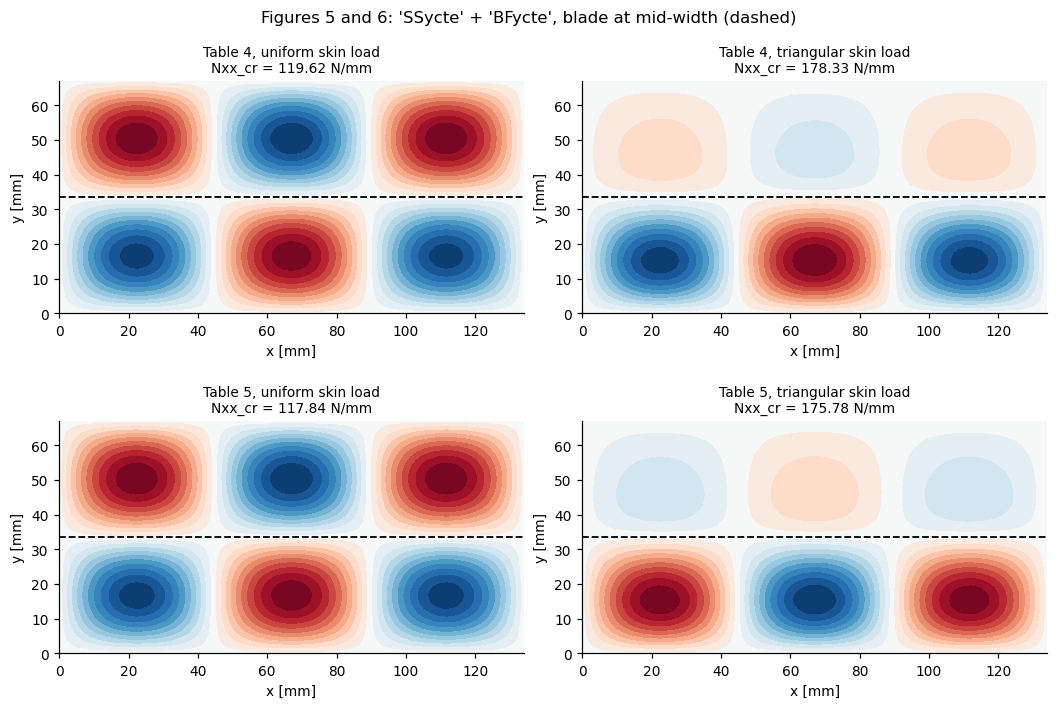

In [12]:
print('w of the skin along the blade line, normalised by max|w| over the skin:')
for key in CASES:
    d = res_t45[key][('edge', 1.)]
    res = d['md'].uvw(d['evec'][:, 0], group='skin', gridx=60, gridy=30)
    wmax = max(np.abs(w).max() for w in res['w'])
    w_line = np.abs(res['w'][0][-1, :]).max()        # y = b/2, strip 1
    print('  %-22s %.4f' % ('%s / %s' % key, w_line/wmax))

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), constrained_layout=True)
for ax, (table, load) in zip(axes.ravel(), CASES):
    d = res_t45[(table, load)][('edge', 1.)]
    plot_md_mode(ax, d['md'], d['evec'][:, 0],
                 'Table %s, %s skin load\nNxx_cr = %.2f N/mm'
                 % (table[-1], load, d['Nxx']), blade_ys=[B_312/2])
fig.suptitle("Figures 5 and 6: 'SSycte' + 'BFycte', blade at mid-width (dashed)")
plt.show()

## 7. Section 3.2.2 / Figure 7 - ten plate-domain blades

Simply supported 500 mm square plates, the five laminations of Table 2, ten equidistant `[0/90]s`
blades of 0.536 mm thickness. The skin is split in eleven `'SSycte'` strips and each blade is attached
with `'BFycte'` to the common edge of two strips, so the model has 21 domains. The blade height is
swept from 0 to 9 mm and `P_cr = Nx_cr b` is compared with the ten `BladeStiff1D` beams of the
companion notebook, which use 16 x 16 terms on a single skin domain, and with the published end
points of each curve. Penalties are raised by `PENALTY_FACTOR`.

The companion notebook explains why the abscissa of Figure 7 is ambiguous; the comparison is again
made against the blade height.

In [13]:
def figure7(stack, height, m=12, n=6, mf=12, nf=4, factor=PENALTY_FACTOR):
    t_skin = len(stack)*PLY_T
    skins, conn = strips(A_322, B_322, stack, N_STIFF_322 + 1, m, n, 'y',
                         factor, laminaprop=LAMINAPROP_311)
    blades = []
    if height > 0:
        for p in skins[:-1]:
            f = blade(A_322, height, STIFF_STACK_322, mf, nf, 'x',
                      laminaprop=LAMINAPROP_311, t_skin=t_skin)
            conn.append(dict(p1=p, p2=f, func='BFycte', ycte1=p.b, ycte2=0.,
                             **penalties(p, f, 'ycte', factor)))
            blades.append(f)
    mdom = MultiDomain(skins + blades, conn)
    size = mdom.get_size()
    kG = sum(kG_linear(p, -1., 0., p.y0, B_322, size) for p in skins)
    ev, evec = buckling(mdom, kG, num_eigvalues=4)
    return ev[0]*B_322, evec, mdom


heights = np.linspace(0., 9.e-3, 10)
res_f7 = {}
t = time.time()
for name, stack in LAMINATES.items():
    P_md, P_sd, modes = [], [], {}
    for h in heights:
        P, evec, mdom = figure7(stack, h)
        P_md.append(P)
        if h == heights[-1]:
            modes = dict(evec=evec, md=mdom)
        skin = spb.make_skin(A_322, B_322, stack, PLY_T, LAMINAPROP_311)
        sts = () if h == 0. else spb.add_stiffeners(
            skin, N_STIFF_322, h, STIFF_STACK_322, PLY_T, LAMINAPROP_311)
        ev, _ = spb.buckling(skin, sts)
        P_sd.append(ev[0]*B_322)
    res_f7[name] = dict(P_md=np.array(P_md), P_sd=np.array(P_sd), mode=modes)
print('Figure 7 sweep: %.0f s' % (time.time() - t))

print('\nP_cr [N], MultiDomain / BladeStiff1D, per cent difference:')
rows = []
for name in LAMINATES:
    d = res_f7[name]
    rows.append([name] + ['%+.1f' % pct(a, b) for a, b in zip(d['P_md'],
                                                               d['P_sd'])])
show(rows, ['lamination'] + ['h=%.0f' % (h*1e3) for h in heights])

Figure 7 sweep: 319 s

P_cr [N], MultiDomain / BladeStiff1D, per cent difference:
                lamination   h=0   h=1   h=2   h=3   h=4   h=5   h=6   h=7   h=8   h=9
--------------------------------------------------------------------------------------
               [0_3/90_3]s  -0.0  +0.3  +0.3  +0.2  +0.1  -0.0  -0.3  -0.6  -0.9  -1.3
       [0_3/90_3/0_3/90_3]  -0.0  +0.2  +0.2  +0.2  +0.1  -0.1  -0.3  -0.6  -0.9  -1.3
   [0_2/45_2/0_2/45_2/0_2]  -0.0  +0.2  +0.2  +0.2  +0.1  -0.1  -0.3  -0.6  -0.9  -1.3
  [0_2/45_2/0_2/-45_2/0_2]  -0.0  +0.3  +0.3  +0.2  +0.1  -0.0  -0.3  -0.6  -0.9  -1.3
                [0_6/60_6]  -0.0  +0.2  +0.1  -0.0  -0.2  -0.4  -0.6  -0.9  -1.2  -1.5


In [14]:
rows = []
for name in LAMINATES:
    d, ref = res_f7[name], PAPER['figure7'][name]
    rows.append([name, '%.0f' % d['P_md'][0], '%.0f' % d['P_sd'][0],
                 '%.0f' % ref['P0_rr'], '%+.0f' % pct(d['P_md'][0], ref['P0_rr']),
                 '%.0f' % ref['P0_fe'], '%+.0f' % pct(d['P_md'][0], ref['P0_fe']),
                 '%.2f' % (np.interp(ref['Pmax_rr'], d['P_md'], heights)*1e3),
                 '%.2f' % (np.interp(ref['Pmax_rr'], d['P_sd'], heights)*1e3)])
show(rows, ['lamination', 'MD P0', '1D P0', 'Fig.7 R-R', 'diff %', 'Fig.7 FE',
            'diff %', 'MD h at Pmax', '1D h at Pmax'])
print('\nP0: unstiffened intercept, no calibration of any kind.')
print('h at Pmax: blade height at which each model reaches the paper R-R value')
print('quoted at the stiff end of the curve.')

                lamination  MD P0  1D P0  Fig.7 R-R  diff %  Fig.7 FE  diff %  MD h at Pmax  1D h at Pmax
---------------------------------------------------------------------------------------------------------
               [0_3/90_3]s   1172   1172       1200      -2      1200      -2          6.22          6.20
       [0_3/90_3/0_3/90_3]   1143   1143       1120      +2      1080      +6          6.04          6.03
   [0_2/45_2/0_2/45_2/0_2]    746    746        660     +13       660     +13          5.14          5.14
  [0_2/45_2/0_2/-45_2/0_2]    718    718        665      +8       660      +9          5.02          5.02
                [0_6/60_6]   1037   1037       1120      -7       840     +23          5.08          5.07

P0: unstiffened intercept, no calibration of any kind.
h at Pmax: blade height at which each model reaches the paper R-R value
quoted at the stiff end of the curve.


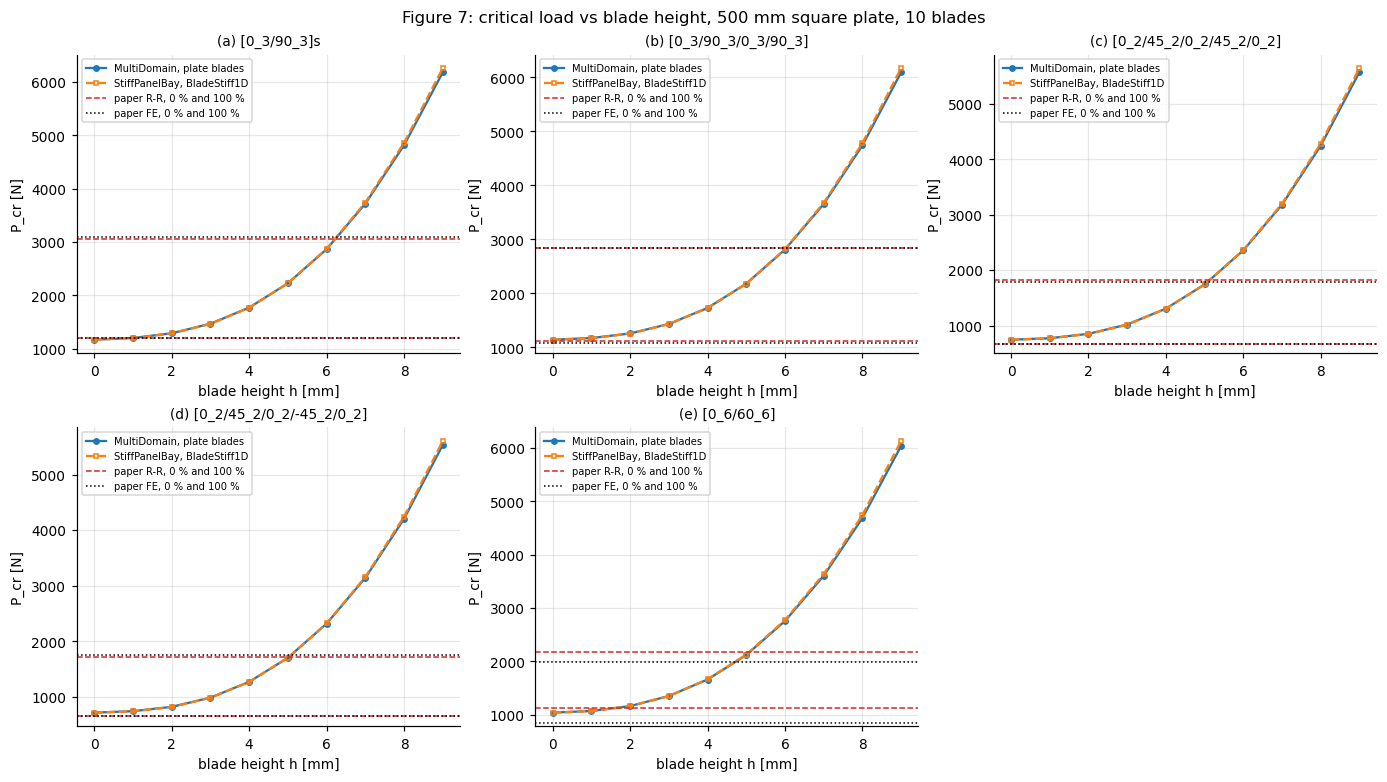

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.0), constrained_layout=True)
labels = '(a) (b) (c) (d) (e)'.split()
for ax, lab, name in zip(axes.ravel(), labels, LAMINATES):
    d, ref = res_f7[name], PAPER['figure7'][name]
    ax.plot(heights*1e3, d['P_md'], '-o', ms=3.5, color='C0',
            label='MultiDomain, plate blades')
    ax.plot(heights*1e3, d['P_sd'], '--s', ms=3, color='C1', mfc='none',
            label='StiffPanelBay, BladeStiff1D')
    ax.axhline(ref['P0_rr'], color='C3', ls='--', lw=1,
               label='paper R-R, 0 % and 100 %')
    ax.axhline(ref['Pmax_rr'], color='C3', ls='--', lw=1)
    ax.axhline(ref['P0_fe'], color='k', ls=':', lw=1,
               label='paper FE, 0 % and 100 %')
    ax.axhline(ref['Pmax_fe'], color='k', ls=':', lw=1)
    ax.set_title('%s %s' % (lab, name), fontsize=9)
    ax.set_xlabel('blade height h [mm]')
    ax.set_ylabel('P_cr [N]')
    ax.legend(fontsize=6.5, loc='upper left')
axes.ravel()[-1].axis('off')
fig.suptitle('Figure 7: critical load vs blade height, 500 mm square plate, '
             '10 blades')
plt.show()

### Figure 8 - modes of the stiffest configuration

The skin deflection of the 21-domain model at `h = 9 mm`, blades dashed.

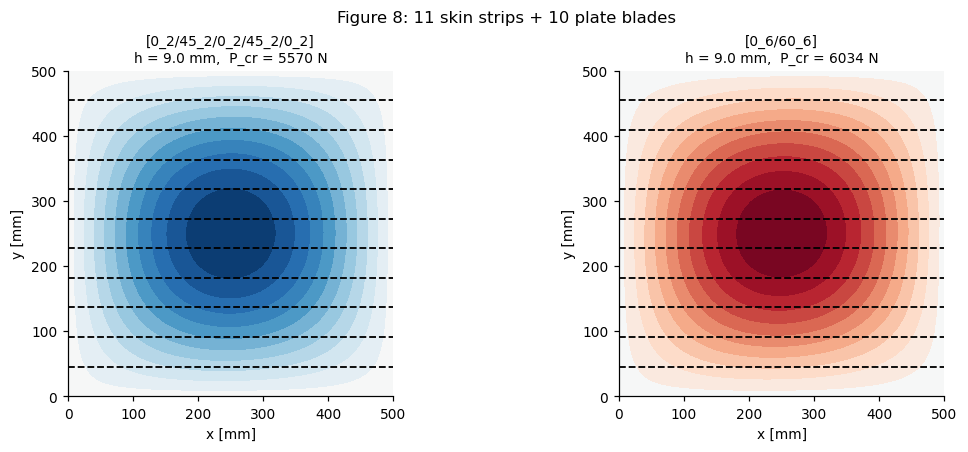

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), constrained_layout=True)
for ax, name in zip(axes, ['[0_2/45_2/0_2/45_2/0_2]', '[0_6/60_6]']):
    d = res_f7[name]
    mdom = d['mode']['md']
    plot_md_mode(ax, mdom, d['mode']['evec'][:, 0],
                 '%s\nh = %.1f mm,  P_cr = %.0f N'
                 % (name, heights[-1]*1e3, d['P_md'][-1]),
                 blade_ys=[p.y0 for p in mdom.panels
                           if p.group == 'skin'][1:], gridx=60, gridy=10)
fig.suptitle('Figure 8: 11 skin strips + 10 plate blades')
plt.show()

## 8. Summary

In [17]:
print('=' * 86)
print('MULTIDOMAIN REPRODUCTION SUMMARY'.center(86))
print('=' * 86)
rows = []
for name in LAMINATES:
    r, ref = res_t2[name], PAPER['table2'][name]
    rows.append(['T2  ' + name, "3 x 'SSxcte'", '%.3f' % r['Nxx'],
                 '%.3f' % ref['rr'], '%+.1f%%' % pct(r['Nxx'], ref['rr']),
                 '%+.3f%%' % pct(r['Nxx'], r['sd'])])
for i, mode in enumerate(['(1, 1)', '(2, 1)', '(3, 1)']):
    ref = PAPER['table3'][mode]
    v = ev_t3[i]/1e3*SCALE
    rows.append(['T3  mode ' + mode, "3 x 'SSycte'", '%.3f' % v,
                 '%.3f' % ref['rr'], '%+.2f%%' % pct(v, ref['rr']),
                 '%+.3f%%' % pct(ev_t3[i], EV_SD_T3[i])])
for func in ('SB', 'SB_TSL'):
    v = res_sb[(func, 'top first')][0]
    # supported on the mid-surface of the top part: not the paper's case
    rows.append(['T3  skin, bonded halves', "'%s'" % func,
                 '%.3f' % (v/1e3*SCALE), '-', '-',
                 '%+.3f%%' % pct(v, ev_mono[0])])
for table, load in CASES:
    r, ref = res_t45[(table, load)], PAPER[table][load]
    v = r[('edge', 1.)]['Nxx']
    rows.append(['T%s  %s' % (table[-1], load), "'BFycte'", '%.2f' % v,
                 '%.2f' % ref['rr'], '%+.1f%%' % pct(v, ref['rr']),
                 '%+.1f%%' % pct(v, r['sd'])])
for name in LAMINATES:
    d, ref = res_f7[name], PAPER['figure7'][name]
    rows.append(['F7  %s, 0%%' % name, "11 x 'SSycte'", '%.0f' % d['P_md'][0],
                 '%.0f' % ref['P0_rr'], '%+.0f%%' % pct(d['P_md'][0], ref['P0_rr']),
                 '%+.2f%%' % pct(d['P_md'][0], d['P_sd'][0])])
show(rows, ['paper item', 'connection', 'MultiDomain', 'paper R-R', 'vs R-R',
            'vs single dom.'])
print()
print('T2 in N/mm, loaded edges clamped. T3-T5 in N/mm with the single factor')
print('calibrated on T3 (1,1) with the single-domain model. F7 in N, no calibration.')
print("'vs single dom.' is against StiffPanelBay: the single Shell for T2 and T3,")
print('the monolithic laminate for SB, and BladeStiff1D for T4, T5 and F7.')
print('The SB skin is supported on the mid-surface of its top part, a different')
print('boundary condition from Table 3, so it is compared with the monolithic')
print('laminate only.')
print('\nnotebook run time: %.0f s' % (time.time() - T0))

                           MULTIDOMAIN REPRODUCTION SUMMARY                           
                        paper item     connection  MultiDomain  paper R-R  vs R-R  vs single dom.
-------------------------------------------------------------------------------------------------
                   T2  [0_3/90_3]s   3 x 'SSxcte'       27.150     26.475   +2.6%         -0.006%
           T2  [0_3/90_3/0_3/90_3]   3 x 'SSxcte'       17.256     17.514   -1.5%         -0.004%
       T2  [0_2/45_2/0_2/45_2/0_2]   3 x 'SSxcte'       15.943     22.789  -30.0%         -0.005%
      T2  [0_2/45_2/0_2/-45_2/0_2]   3 x 'SSxcte'       15.027     20.426  -26.4%         -0.005%
                    T2  [0_6/60_6]   3 x 'SSxcte'       12.110     17.788  -31.9%         +0.001%
                   T3  mode (1, 1)   3 x 'SSycte'       67.735     67.749  -0.02%         -0.021%
                   T3  mode (2, 1)   3 x 'SSycte'       69.440     69.298  +0.20%         -0.006%
                   T3  mode (3,

### What reproduces, and how well

| paper item | `MultiDomain` model | vs paper R-R | vs single domain / `BladeStiff1D` |
|---|---|---|---|
| Table 2, five laminates | 3 `'SSxcte'` strips | same as single domain (+2.6 % to -31.9 %) | **within 0.006 %** |
| Table 3, all three modes | 3 `'SSycte'` strips | **-0.02 % / +0.20 % / -0.31 %** | **within 0.021 %** |
| Table 3 skin, through the thickness | `'SB'` and `'SB_TSL'` | not comparable (see section 5) | **-0.049 %**, both orders |
| Table 4 | `'SSycte'` + `'BFycte'` | **+0.0 % / +3.1 %** | +3.8 % / +1.4 % |
| Table 5 | idem | **-0.5 % / -4.5 %** | +2.3 % / +0.0 % |
| Tables 4 and 5, rotated | `'SSxcte'` + `'BFxcte'` | identical to `'BFycte'` | rotated vs edge within **1.4e-13** |
| Figure 7, unstiffened intercepts | 11 `'SSycte'` strips | **-7 % to +13 %**, no calibration | within 0.02 % |
| Figure 7, `h` = 1 to 9 mm | 11 strips + 10 `'BFycte'` blades | same as `BladeStiff1D` | **+0.3 % to -1.5 %** |

**Skin connections.** With the penalties raised by `PENALTY_FACTOR = 100`, `'SSycte'` and `'SSxcte'`
recover the single domain to four or five significant digits, and 12 x 8 terms per strip are
converged. With the default `calc_kt_kr()` values the error is about -2 % for strips joined along
the load (`'SSycte'`, mode 1) and -1 % across it (`'SSxcte'`, mode 2). It falls linearly with the
penalty factor, which shows that the rotation penalty `kr` governs it for these thin skins. The
error is always negative, as a penalty method must give.

**Bonded sub-laminates.** `'SB'` and `'SB_TSL'` rebuild the bending-extension coupling of the
unsymmetric `[0/90/90/0/0]` skin from two sub-laminates with different `B`, through the offset of
their mid-surfaces, to 0.05 % and independently of the assembly order. The value `kt = 2e5`
hard-coded up to panels 0.6.9 was in N/mm³; in SI units it left the halves practically unbonded
(-84 %).

**Blade as a plate.** Tables 4 and 5 stay within 4.5 % of the paper with the same factor, calibrated
on a different table, as with `BladeStiff1D`. The plate blade is up to 3.8 % stiffer than the beam.
In the uniform-load case it is also the closer of the two to the paper's R-R value (+0.0 % and
-0.5 %, against -3.7 % and -2.7 % for the beam). The differences between the plate and the beam
are:

* the plate blade can twist and bend laterally, and its root rotation is tied to the skin by `kr`,
  whereas the beam of `BladeStiff1D` only follows the skin deflection;
* the node on the blade line that `BladeStiff1D` enforces exactly is only approximate here:
  `w/max|w|` on the blade line is 0.004 for the uniform load and 0.03 for the triangular one, where
  the mode concentrates in the more heavily loaded half (Figures 5 and 6). For the same reason the
  loaded blade lowers the uniform-load result slightly (119.62 to 117.84 N/mm), in the direction the
  paper also reports (119.60 to 118.45). The beam gives no change at all.

Attaching the blade at a strip edge or along an interior line of a single skin domain gives the same
result to within 0.6 %.

**Ten blades.** In the global mode of Figure 7 the plate blades bend with the skin, and the two blade
models agree within 1.5 % over the whole sweep, while `P_cr` grows five times. The plate model
becomes slightly softer than the beam for tall blades, where the blade's own shear and
lateral-torsional flexibility start to count. The heights at which each model reaches the paper's
100 % value agree to 0.02 mm. The conclusions of the companion notebook on the stiffened branch of
Figure 7 therefore do not depend on the blade formulation.

### Reproducing this notebook

All of the above is checked as unit tests in
`tests/multidomain/test_stamatelos_labeas_2023_multidomain.py`, which imports the same `PAPER`
dictionary as `tests/tests_stiffpanelbay/test_stamatelos_labeas_2023.py`. The notebook runs in
about 7 minutes, most of it in the Figure 7 sweep.